In [1]:
#import necessary libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from matplotlib.ticker import AutoMinorLocator

import xarray as xr
import scipy

from scipy import stats
from scipy.stats import pearsonr, linregress

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

import time
from datetime import datetime, date

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.dates as mdates


import shapefile
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
import os

import sys
import os.path
import subprocess
import math
import csv

from netCDF4 import Dataset

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr

import warnings
warnings.filterwarnings("ignore")

In [2]:
# 1. Load both CSVs

wgh = pd.read_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/WGAP_HM/New_HMA_RegionalAvergaed_anomalies_wghTWS.csv', parse_dates=[0])
grace = pd.read_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/SH_EWA_SECorerected_RA_sol_scaled_region_sorted.csv', parse_dates=[0])

# New_EnsembleWeightedAverageMascon1.csv

# 2. Ensure the date columns are named 'date' and are datetime
wgh = wgh.rename(columns={wgh.columns[0]: 'date'})
grace = grace.rename(columns={grace.columns[0]: 'date'})


# 3. Merge on date (outer join to keep all months)
df = pd.merge(grace, wgh, on='date', how='outer', suffixes=('_GRACE', '_WGH'))
df = df.sort_values('date').reset_index(drop=True)

# 4. Fill missing months (reindex to monthly frequency)
full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='M')
df = df.set_index('date').reindex(full_range).rename_axis('date').reset_index()

# 5. Gap-fill each region using cubic interpolation (or SSA if you prefer)
for col in df.columns:
    if col != 'date':
        df[col] = df[col].interpolate(method='linear', limit_direction='both')

# 6. Identify region names (e.g., "Hindu Kush", "Western Himalaya", ...)
region_names = [col.replace('_GRACE', '') for col in df.columns if col.endswith('_GRACE')]

# 7. Compute glacier signal for each region
for region in region_names:
    df[f'{region}'] = df[f'{region}_GRACE'] - df[f'{region}_WGH'] #df[f'{region}_glacier'] = df[f'{region}_GRACE'] - df[f'{region}_WGH']
    #df[f'{region}'] = df[f'{region}_GRACE'] - df[f'{region}_GLDAS'] #df[f'{region}_glacier'] = df[f'{region}_GRACE'] - df[f'{region}_GLDAS']
    

# 8. Save the glacier signal for all regions
glacier_cols = ['date'] + [f'{region}' for region in region_names] #glacier_cols = ['date'] + [f'{region}_glacier' for region in region_names]
df[glacier_cols].to_csv('HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv', index=False)

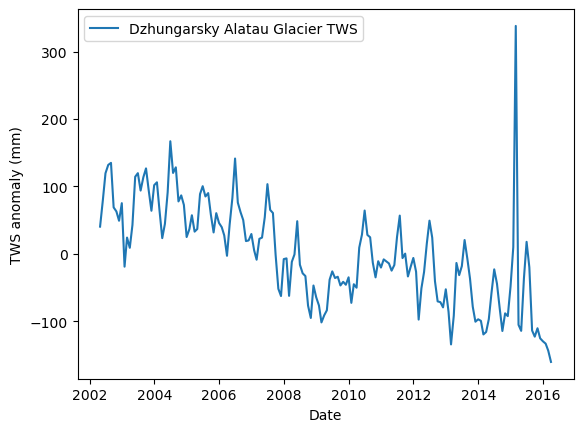

In [3]:
# 9. (Optional) Plot for one region
import matplotlib.pyplot as plt
plt.plot(df['date'], df[f'{region_names[0]}'], label=f'{region_names[0]} Glacier TWS')
plt.xlabel('Date')
plt.ylabel('TWS anomaly (mm)')
plt.legend()
plt.show()

In [4]:
# Open the CSV file, parsing the 'date' column as datetime if needed
# df = pd.read_csv('HMA_RegionalAveraged_TWS_GlacierSignal.csv', parse_dates=['date'])
df = pd.read_csv('HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv', parse_dates=['date'])

# Rename the column 'date' to 'time'
df = df.rename(columns={'date': 'time'})

# (Optional) Save the updated DataFrame back to CSV
df.to_csv('Updated_HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv', index=False)

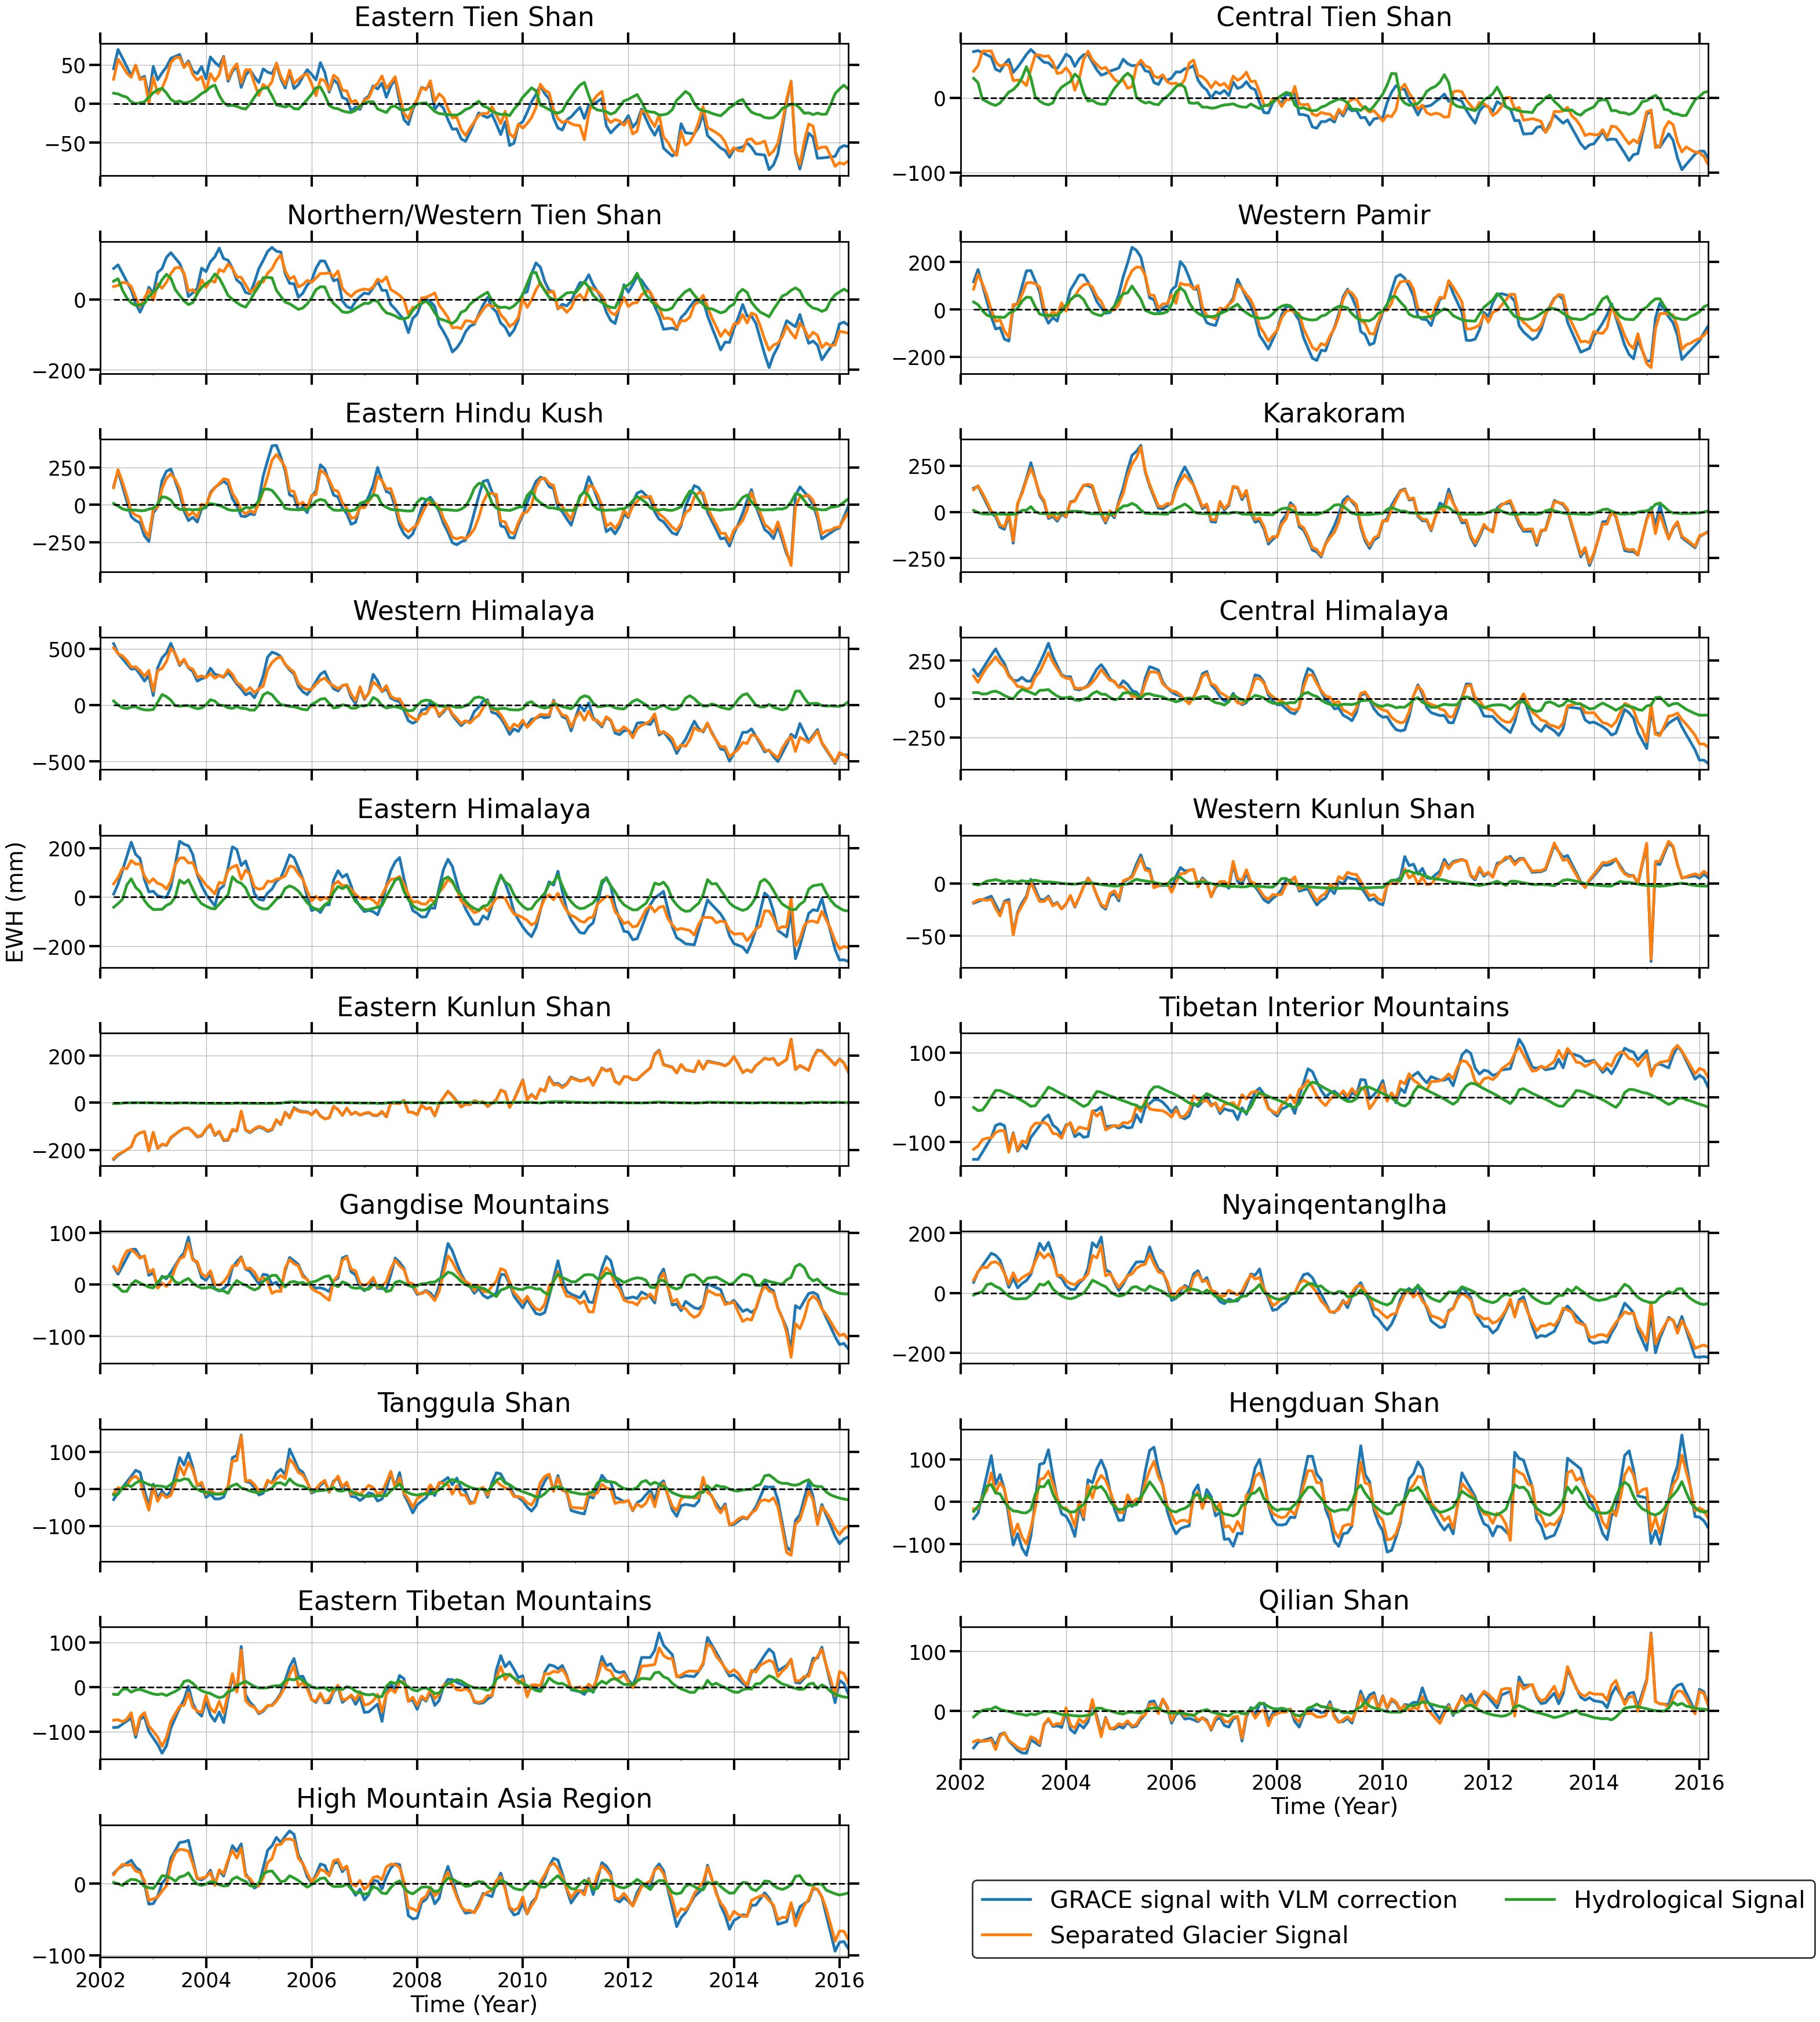

In [5]:
# Define datasets
datasets = {
    "GRACE signal with VLM correction": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/SH_EWA_SECorerected_RA_sol_scaled_region_sorted.csv",
    "Separated Glacier Signal": "Updated_HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv", #date column renamed as time to make consistency with others
    "Hydrological Signal": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/WGAP_HM/New_HMA_RegionalAvergaed_anomalies_wghTWS.csv" #New_HMA_RegionalAvergaed_anomalies_wghTWS.csv
}

dataset_colors = {
    "GRACE signal with VLM correction": "#1f77b4",       # Blue
    "Separated Glacier Signal": "#ff7f0e",   # Orange
    "Hydrological Signal": "#2ca02c"         # Green
}

# Load region metadata
region_metadata = pd.DataFrame({
    'region': [
        'Eastern Hindu Kush', 'Western Himalaya', 'Eastern Himalaya', 'Central Himalaya', 'Karakoram',
        'Western Pamir', 'Northern/Western Tien Shan', 'Western Kunlun Shan', 'Nyainqentanglha', 'Gangdise Mountains', 'Hengduan Shan',
        'Tibetan Interior Mountains', 'Tanggula Shan', 'Eastern Tibetan Mountains', 'Qilian Shan', 'Eastern Kunlun Shan',
        'Eastern Tien Shan', 'Central Tien Shan', 'High Mountain Asia Region'
    ],
    'region_id': [8, 10, 12, 11, 9, 6, 4, 13, 18, 17, 20, 16, 19, 21, 22, 14, 2, 3, 23]
})
region_metadata_sorted = region_metadata.sort_values(by='region_id')
sorted_regions = region_metadata_sorted['region'].values

# Load and preprocess all datasets
dfs = {}
for name, file in datasets.items():
    df = pd.read_csv(file)
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    dfs[name] = df[sorted_regions]  # Ensure consistent region order

# # Create colormap for datasets
# colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

# Setup figure
fig, axes = plt.subplots(10, 2, figsize=(30, 36), sharex=True, sharey=False)
axes = axes.flatten()

# Generate x-ticks
time_index = dfs[list(datasets.keys())[0]].index
start_year = time_index.min().year
end_year = time_index.max().year
x_ticks = pd.date_range(start=f'{start_year}', end=f'{end_year}', freq='2YS')

# Plot each region with all datasets
for i, (_, row) in enumerate(region_metadata_sorted.iterrows()):
    region = row['region']
    region_id = row['region_id']
    ax = axes[i]
    
    # # Plot each dataset for current region
    # for j, (name, df) in enumerate(dfs.items()):
    #     df[region].plot(ax=ax, color=colors[j], label=name, linewidth=2)

    for name, df in dfs.items():
        df[region].plot(
            ax=ax,
            color=dataset_colors[name],
            label=name,
            linewidth=3.5
        )
    
    # ax.set_title(region, fontsize=22)
    ax.set_title(region, fontsize=33, pad=22)
    ax.grid(True)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([tick.year for tick in x_ticks], rotation=0)
    
    # ax.tick_params(axis='x', labelsize=22, direction='out', top=True, bottom=True, length=7.5, width=0.8)
    # ax.tick_params(axis='y', labelsize=22, direction='out', left=True, right=True, length=7.5, width=0.8)
    ax.tick_params(axis='x', labelsize=25, direction='out', top=True, bottom=True, length=14, width=3)
    ax.tick_params(axis='y', labelsize=25, direction='out', left=True, right=True, length=14, width=3)
    
    
    ax.hlines(0, time_index.min(), time_index.max(), colors='k', linestyles='--', linewidth=2)
    
    # # Add region ID
    # ax.text(0.95, 0.95, f"{region_id}", transform=ax.transAxes,
    #         fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left',
    #         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round, pad=0.2', linewidth=1))

for ax in axes:   #setting rectangular box for each subplot, adjusting the width of the edge of the box
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

# Add labels and legend
axes[8].set_ylabel('EWH (mm)', fontsize=28)

axes[17].set_xlabel('Time (Year)', fontsize=28)

axes[18].set_xlabel('Time (Year)', fontsize=28)

# Make sure x-tick labels are visible on bottom row axes
axes[17].tick_params(labelbottom=True)

axes[17].xaxis.get_label().set_visible(True)

# === LEGEND PLACEMENT ===
legend = axes[18].legend(
    list(datasets.keys()),
    loc='center left',
    bbox_to_anchor=(1.15, 0.29),  # Adjust horizontal position as needed
    ncol=2,
    fontsize=30,
    frameon=True
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2)     

axes[18].tick_params(labelbottom=True)


# fig.legend(list(datasets.keys()), loc='lower center', 
#            bbox_to_anchor=(0.52, -0.03), ncol=5, fontsize=30)

# Remove unused subplots
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

# Final adjustments
plt.tight_layout()
plt.subplots_adjust(top=0.95, wspace=0.15)
plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Figures/Thesis_TimeSeries/Approaches/Wahr_approach/SH_VCE_EWA_GRACESignal_withVLM_corr_HS_GS_timeseries_no_sharey_withoutEnvelope.png', dpi=300, bbox_inches='tight')
plt.show()

-----
------

In [6]:
# 1. Load and prepare the shapefile
gdf = gpd.read_file(r'D:\MSRSGI\Masters_thesis\Data\HMA_Region_Shapefiles\Regions_shapefiles\New folder\Updated_TotalHMA_boundary1_22.shp')
gdf_4326 = gdf.to_crs('EPSG:4326')  # Reproject to match dataset CRS

dropped_gdf_4326 = gdf_4326.drop(['Primary__1', 'Glacier_Ar'], axis=1)
dropped_gdf_4326

,Primary_ID,Area,Shape_Area,Region_No,geometry
0,Eastern Hindu Kush,111147.061871,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,211514.200081,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,166943.561268,1.669436e+11,12,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,270268.094462,2.702681e+11,11,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,92830.485352,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,124880.500694,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,83444.425531,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,205724.916795,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,39543.166059,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,132813.049169,1.328130e+11,13,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [7]:
gdf1 = gpd.read_file(r"D:\MSRSGI\Masters_thesis\Data\HMA_Region_Shapefiles\Regions_shapefiles\New folder\Updated_SingleHMAboundarythatincludes1to22.shp")
gdf1_4326 = gdf1.to_crs('EPSG:4326')  # Reproject to match dataset CRS

dropped_gdf1_4326 = gdf1_4326.drop(['Primary__1', 'Glacier_Ar'], axis=1)  #already done , so comes weror wehn done
dropped_gdf1_4326

,Primary_ID,Area,Shape_Area,Region_No,geometry
0,High Mountain Asia Region,3.993978e+06,3.993978e+12,23,"POLYGON ((92.26394 39.3763, 92.24847 39.32136,..."


In [8]:
gdf_concat = pd.concat([dropped_gdf_4326, dropped_gdf1_4326 ], axis=0, ignore_index=True)
gdf_concat

,Primary_ID,Area,Shape_Area,Region_No,geometry
0,Eastern Hindu Kush,1.111471e+05,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,2.115142e+05,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,1.669436e+05,1.669436e+11,12,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,2.702681e+05,2.702681e+11,11,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,9.283049e+04,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,1.248805e+05,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,8.344443e+04,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,2.057249e+05,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,3.954317e+04,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,1.328130e+05,1.328130e+11,13,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [9]:
glaciersignal_mmwe = pd.read_csv('Updated_HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv')
glaciersignal_mmwe

,time,Dzhungarsky Alatau,Eastern Tien Shan,Central Tien Shan,Northern/Western Tien Shan,Pamir Alay,Western Pamir,Eastern Pamir,Eastern Hindu Kush,Karakoram,...,Eastern Kunlun Shan,Altun Shan,Tibetan Interior Mountains,Gangdise Mountains,Nyainqentanglha,Tanggula Shan,Hengduan Shan,Eastern Tibetan Mountains,Qilian Shan,High Mountain Asia Region
0,2002-04-30,40.353454,31.359449,35.781254,36.138361,26.157169,85.709711,22.718139,113.640528,119.744531,...,-236.930746,-74.024643,-116.025906,34.524766,42.784044,-12.711733,-17.274597,-74.376218,-52.118158,12.612978
1,2002-05-31,79.196594,56.893413,43.126126,39.235430,72.770525,148.304995,33.423159,234.239265,141.594531,...,-219.517467,-58.634755,-109.072134,25.065241,70.739150,3.432958,-15.624394,-73.243417,-48.939405,20.850401
2,2002-06-30,119.560198,48.618335,62.626388,47.875635,57.821447,108.713366,20.123915,152.865487,101.389473,...,-209.495008,-58.576483,-94.589496,49.058831,86.337243,0.559174,11.224972,-77.836555,-51.338702,27.414547
3,2002-07-31,131.874320,39.006304,62.688281,46.273815,34.618921,59.782086,6.990948,58.716528,54.657807,...,-198.775476,-57.286451,-91.366260,64.802038,84.094839,8.100126,26.329979,-71.938870,-50.376484,25.992745
4,2002-08-31,134.937933,33.684856,62.916840,36.330511,-1.901448,-0.639668,-6.630708,-44.520913,4.682373,...,-186.263328,-56.157086,-90.846237,67.451349,101.209148,27.932095,67.937150,-57.659789,-48.477169,26.737434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2015-11-30,-125.327756,-66.973103,-69.642648,-132.438184,-164.748367,-143.183398,-36.678863,-170.166601,-167.648315,...,180.311574,68.775350,69.615576,-72.163870,-149.324109,-82.431348,32.074511,16.902164,8.209112,-57.385480
164,2015-12-31,-129.695508,-80.333303,-72.738211,-129.147560,-160.484250,-130.978829,-35.519485,-152.632264,-187.238332,...,159.673588,61.589190,52.290475,-87.188412,-185.360821,-106.388369,-21.537231,-19.552337,-5.088104,-80.515163
165,2016-01-31,-133.217210,-75.592949,-73.363704,-90.729289,-102.604397,-123.547649,-18.693125,-148.387030,-128.921778,...,184.759814,67.077714,64.700354,-99.249313,-178.905209,-123.209555,-14.423059,34.519498,33.061295,-66.283629
166,2016-02-29,-143.578290,-77.445432,-78.775309,-93.288122,-79.572483,-110.479902,-17.850316,-98.743763,-118.916873,...,168.058318,61.230724,60.966257,-96.056955,-173.955865,-107.608026,-20.456698,30.315035,29.241278,-66.502969


In [10]:
gdf_concat

,Primary_ID,Area,Shape_Area,Region_No,geometry
0,Eastern Hindu Kush,1.111471e+05,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,2.115142e+05,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,1.669436e+05,1.669436e+11,12,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,2.702681e+05,2.702681e+11,11,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,9.283049e+04,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,1.248805e+05,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,8.344443e+04,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,2.057249e+05,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,3.954317e+04,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,1.328130e+05,1.328130e+11,13,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [11]:
# glaciersignal_mmwe: pandas DataFrame loaded with time index and sub-region columns
# area_df: DataFrame or GeoDataFrame with region names and Shape_Area in m²

# Set index on region name for area lookup; adjust 'region' to your actual column name
area_series = gdf_concat.set_index('Primary_ID')['Shape_Area']

# Prepare glacier signal DataFrame with time as index
mm_data = glaciersignal_mmwe.set_index('time')

# Ensure area order matches the column order of glacier signal
area = area_series.loc[mm_data.columns]

# Convert mm to Gt: multiply each region column by its area and divide by 1e12
signal_gt = mm_data.multiply(area, axis=1) / 1e12

# Optional: reset index if needed or save
signal_gt = signal_gt.reset_index()
signal_gt

,time,Dzhungarsky Alatau,Eastern Tien Shan,Central Tien Shan,Northern/Western Tien Shan,Pamir Alay,Western Pamir,Eastern Pamir,Eastern Hindu Kush,Karakoram,...,Eastern Kunlun Shan,Altun Shan,Tibetan Interior Mountains,Gangdise Mountains,Nyainqentanglha,Tanggula Shan,Hengduan Shan,Eastern Tibetan Mountains,Qilian Shan,High Mountain Asia Region
0,2002-04-30,1.595703,4.522299,4.005609,7.434561,2.182670,10.703472,0.999042,12.630811,11.115943,...,-61.856374,-4.163163,-63.346083,5.647029,7.435170,-1.857343,-6.439929,-24.799469,-10.515743,50.375957
1,2002-05-31,3.131684,8.204513,4.827847,8.071706,6.072295,18.520402,1.469801,26.035006,13.144289,...,-57.310225,-3.297632,-59.549566,4.099786,12.293312,0.501598,-5.824737,-24.421756,-9.874374,83.276045
2,2002-06-30,4.727789,7.011177,7.010845,9.849211,4.824877,13.576180,0.884960,16.990550,9.412034,...,-54.693625,-3.294355,-51.642553,8.024287,15.004007,0.081702,4.184643,-25.953259,-10.358474,109.493098
3,2002-07-31,5.214728,5.625040,7.017774,9.519677,2.888756,7.465617,0.307431,6.526170,5.073911,...,-51.895038,-3.221803,-49.882779,10.599319,14.614313,1.183529,9.815754,-23.986778,-10.164330,103.814454
4,2002-08-31,5.335873,4.857642,7.043360,7.474091,-0.158665,-0.079882,-0.291589,-4.948369,0.434667,...,-48.628446,-3.158287,-49.598865,11.032652,17.588502,4.081227,25.326809,-19.225664,-9.781110,106.788725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2015-11-30,-4.955856,-9.658090,-7.796295,-27.245834,-13.747333,-17.880814,-1.612973,-18.913518,-15.562874,...,47.074600,3.867941,38.007667,-11.803454,-25.950098,-12.044247,11.957302,5.635736,1.656331,-229.196348
164,2015-12-31,-5.128571,-11.584744,-8.142835,-26.568871,-13.391516,-16.356702,-1.561988,-16.964628,-17.381425,...,41.686566,3.463790,28.548768,-14.260937,-32.212692,-15.544666,-8.029029,-6.519390,-1.026613,-321.575791
165,2016-01-31,-5.267830,-10.901145,-8.212857,-18.665276,-8.561765,-15.428692,-0.822040,-16.492782,-11.967871,...,48.235918,3.772466,35.324128,-16.233673,-31.090812,-18.002451,-5.376882,11.509932,6.670690,-264.735357
166,2016-02-29,-5.677540,-11.168289,-8.818671,-19.191691,-6.639880,-13.796786,-0.784977,-10.975079,-11.039111,...,43.875598,3.443630,33.285442,-15.711516,-30.230696,-15.722873,-7.626209,10.108027,5.899935,-265.611399


In [12]:
signal_gt.to_csv('Updated_HMA_RegionalAveraged_TWS_GlacierSignal_inGT_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv', index=False)

In [13]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# Load your data
df = pd.read_csv('Updated_HMA_RegionalAveraged_TWS_GlacierSignal_inGT_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv', parse_dates=['time'])

# Updated_HMA_RegionalAveraged_TWS_GlacierSignal_for_VCEMascon_with_VLM_corr_withAnomaliesWGH.csv

t_ns = df['time'].view('int64').values
YEAR_NS = 365.25 * 24 * 60 * 60 * 1e9

def decomp_func(t, a, b, c, d, e, f):
    t = t / YEAR_NS
    linear = a + b * t
    annual = c * np.sin(2 * np.pi * t) + d * np.cos(2 * np.pi * t)
    semian = e * np.sin(4 * np.pi * t) + f * np.cos(4 * np.pi * t)
    return linear + annual + semian

results = {}
uncertainties = {}

for region in df.columns.drop('time'):
    y = df[region].values
    mask = np.isfinite(y)
    if mask.sum() < 6:
        continue
    try:
        params, pcov = curve_fit(
            decomp_func, t_ns[mask], y[mask], p0=[np.nanmean(y), 0, 0, 0, 0, 0]
        )
        results[region] = params

        if pcov is not None:
            uncertainties[region] = 2 * np.sqrt(np.abs(np.diag(pcov)))  # 2-sigma uncertainties for all params
        else:
            uncertainties[region] = np.full(6, np.nan)
    except RuntimeError:
        results[region] = np.full(6, np.nan)
        uncertainties[region] = np.full(6, np.nan)

summary = []

for region, params in results.items():
    if params is None or np.any(np.isnan(params)):
        continue
    a, b, c, d, e, f = params
    unc = uncertainties[region]
    unc_c, unc_d, unc_e, unc_f = unc[2], unc[3], unc[4], unc[5]

    # Annual amplitude and uncertainty (error propagation)
    amp_annual = np.sqrt(c**2 + d**2)
    amp_annual_unc = (1 / amp_annual) * np.sqrt((c * unc_c)**2 + (d * unc_d)**2) if amp_annual != 0 else np.nan

    # Annual phase and uncertainty (propagation of uncertainty)
    phase_annual_rad = np.arctan2(-d, c)
    denom_annual = c**2 + d**2
    phase_annual_unc_rad = np.sqrt(
        (d / denom_annual)**2 * unc_c**2 +
        (c / denom_annual)**2 * unc_d**2
    ) if denom_annual != 0 else np.nan
    phase_annual_deg = np.degrees(phase_annual_rad)
    phase_annual_unc_deg = np.degrees(phase_annual_unc_rad)

    # Semi-annual amplitude and uncertainty
    amp_semi = np.sqrt(e**2 + f**2)
    amp_semi_unc = (1 / amp_semi) * np.sqrt((e * unc_e)**2 + (f * unc_f)**2) if amp_semi != 0 else np.nan

    # Semi-annual phase and uncertainty
    phase_semi_rad = np.arctan2(-f, e)
    denom_semi = e**2 + f**2
    phase_semi_unc_rad = np.sqrt(
        (f / denom_semi)**2 * unc_e**2 +
        (e / denom_semi)**2 * unc_f**2
    ) if denom_semi != 0 else np.nan
    phase_semi_deg = np.degrees(phase_semi_rad)
    phase_semi_unc_deg = np.degrees(phase_semi_unc_rad)

    summary.append({
        'Region': region,
        'Annual Amplitude (mm w.e.)': amp_annual,
        'Annual Amplitude 2-sigma': amp_annual_unc,
        'Annual Phase (deg)': phase_annual_deg,
        'Annual Phase 2-sigma (deg)': phase_annual_unc_deg,
        'Semi-annual Amplitude (mm w.e.)': amp_semi,
        'Semi-annual Amplitude 2-sigma': amp_semi_unc,
        'Semi-annual Phase (deg)': phase_semi_deg,
        'Semi-annual Phase 2-sigma (deg)': phase_semi_unc_deg,
        'Linear Trend (mm w.e./yr)': b,
        'Linear Trend 2-sigma': unc[1]
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

                        Region  Annual Amplitude (mm w.e.)  \
0           Dzhungarsky Alatau                    1.215001   
1            Eastern Tien Shan                    1.710182   
2            Central Tien Shan                    1.207504   
3   Northern/Western Tien Shan                    6.161366   
4                   Pamir Alay                    4.834841   
5                Western Pamir                    9.643069   
6                Eastern Pamir                    0.917158   
7           Eastern Hindu Kush                   14.373309   
8                    Karakoram                    9.244489   
9             Western Himalaya                   15.085264   
10            Central Himalaya                   20.476187   
11            Eastern Himalaya                    7.714731   
12         Western Kunlun Shan                    1.223420   
13         Eastern Kunlun Shan                    4.302873   
14                  Altun Shan                    0.193934   
15  Tibe

In [14]:
summary_df

,Region,Annual Amplitude (mm w.e.),Annual Amplitude 2-sigma,Annual Phase (deg),Annual Phase 2-sigma (deg),Semi-annual Amplitude (mm w.e.),Semi-annual Amplitude 2-sigma,Semi-annual Phase (deg),Semi-annual Phase 2-sigma (deg),Linear Trend (mm w.e./yr),Linear Trend 2-sigma
0,Dzhungarsky Alatau,1.215001,0.422680,105.681920,19.867503,0.834724,0.422900,-70.031608,28.870650,-0.499275,0.073920
1,Eastern Tien Shan,1.710182,0.496564,89.047736,16.572950,0.460040,0.496843,-74.514841,61.504436,-1.107522,0.086816
2,Central Tien Shan,1.207504,0.290731,110.028464,13.754885,0.726203,0.291131,-82.051723,22.813468,-0.871150,0.050852
3,Northern/Western Tien Shan,6.161366,1.357327,55.848012,12.604268,1.544245,1.359535,-72.496318,50.150473,-2.391364,0.237592
4,Pamir Alay,4.834841,0.777808,41.537391,9.221731,0.201064,0.775098,166.277888,222.268123,-0.764201,0.136278
5,Western Pamir,9.643069,1.361850,58.776705,8.077381,1.609177,1.363030,-114.587889,48.307135,-1.321771,0.238342
6,Eastern Pamir,0.917158,0.161037,45.863990,10.059006,0.164647,0.160884,-137.694119,56.023553,-0.126016,0.028207
7,Eastern Hindu Kush,14.373309,1.752548,59.443042,6.973254,2.193294,1.747140,-148.437756,45.787333,-1.385601,0.306707
8,Karakoram,9.244489,1.340531,56.141189,8.296379,0.681974,1.337797,-141.136417,112.564037,-1.424873,0.234648
9,Western Himalaya,15.085264,3.081671,84.734495,11.660777,1.338811,3.082083,111.689513,131.222949,-12.663901,0.538799


In [15]:
summary_df['Annual Amplitude ± 2σ (mm w.e.)'] = summary_df.apply(
    lambda row: f"{row['Annual Amplitude (mm w.e.)']:.3f} ± {row['Annual Amplitude 2-sigma']:.3f}",
    axis=1
)

summary_df['Semi-annual Amplitude ± 2σ (mm w.e.)'] = summary_df.apply(
    lambda row: f"{row['Semi-annual Amplitude (mm w.e.)']:.3f} ± {row['Semi-annual Amplitude 2-sigma']:.3f}",
    axis=1
)

summary_df['Annual Phase ± 2σ (deg)'] = summary_df.apply(
    lambda row: f"{row['Annual Phase (deg)']:.3f} ± {row['Annual Phase 2-sigma (deg)']:.3f}",
    axis=1
)

summary_df['Semi-annual Phase ± 2σ (deg)'] = summary_df.apply(
    lambda row: f"{row['Semi-annual Phase (deg)']:.3f} ± {row['Semi-annual Phase 2-sigma (deg)']:.3f}",
    axis=1
)

summary_df['Linear Trend ± 2σ (mm w.e./yr)'] = summary_df.apply(
    lambda row: f"{row['Linear Trend (mm w.e./yr)']:.3f} ± {row['Linear Trend 2-sigma']:.3f}",
    axis=1
)

# Optionally, drop original separate columns if no longer needed
cols_to_drop = [
    'Annual Amplitude (mm w.e.)', 'Annual Amplitude 2-sigma',
    'Semi-annual Amplitude (mm w.e.)', 'Semi-annual Amplitude 2-sigma',
    'Annual Phase (deg)', 'Annual Phase 2-sigma (deg)',
    'Semi-annual Phase (deg)', 'Semi-annual Phase 2-sigma (deg)',
    'Linear Trend (mm w.e./yr)', 'Linear Trend 2-sigma'
]
summary_df.drop(columns=cols_to_drop, inplace=True)

summary_df[['Region',
                  'Annual Amplitude ± 2σ (mm w.e.)',
                  'Annual Phase ± 2σ (deg)',
                  'Semi-annual Amplitude ± 2σ (mm w.e.)',
                  'Semi-annual Phase ± 2σ (deg)',
                  'Linear Trend ± 2σ (mm w.e./yr)'
                 ]]

,Region,Annual Amplitude ± 2σ (mm w.e.),Annual Phase ± 2σ (deg),Semi-annual Amplitude ± 2σ (mm w.e.),Semi-annual Phase ± 2σ (deg),Linear Trend ± 2σ (mm w.e./yr)
0,Dzhungarsky Alatau,1.215 ± 0.423,105.682 ± 19.868,0.835 ± 0.423,-70.032 ± 28.871,-0.499 ± 0.074
1,Eastern Tien Shan,1.710 ± 0.497,89.048 ± 16.573,0.460 ± 0.497,-74.515 ± 61.504,-1.108 ± 0.087
2,Central Tien Shan,1.208 ± 0.291,110.028 ± 13.755,0.726 ± 0.291,-82.052 ± 22.813,-0.871 ± 0.051
3,Northern/Western Tien Shan,6.161 ± 1.357,55.848 ± 12.604,1.544 ± 1.360,-72.496 ± 50.150,-2.391 ± 0.238
4,Pamir Alay,4.835 ± 0.778,41.537 ± 9.222,0.201 ± 0.775,166.278 ± 222.268,-0.764 ± 0.136
5,Western Pamir,9.643 ± 1.362,58.777 ± 8.077,1.609 ± 1.363,-114.588 ± 48.307,-1.322 ± 0.238
6,Eastern Pamir,0.917 ± 0.161,45.864 ± 10.059,0.165 ± 0.161,-137.694 ± 56.024,-0.126 ± 0.028
7,Eastern Hindu Kush,14.373 ± 1.753,59.443 ± 6.973,2.193 ± 1.747,-148.438 ± 45.787,-1.386 ± 0.307
8,Karakoram,9.244 ± 1.341,56.141 ± 8.296,0.682 ± 1.338,-141.136 ± 112.564,-1.425 ± 0.235
9,Western Himalaya,15.085 ± 3.082,84.734 ± 11.661,1.339 ± 3.082,111.690 ± 131.223,-12.664 ± 0.539


In [16]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# Load your data
df = pd.read_csv('Updated_HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv', parse_dates=['time'])

# Time in nanoseconds (all regions share the same time index)
t_ns = df['time'].view('int64').values

YEAR_NS = 365.25 * 24 * 60 * 60 * 1e9

def decomp_func(t, a, b, c, d, e, f):
    t = t / YEAR_NS
    linear = a + b * t
    annual = c * np.sin(2 * np.pi * t) + d * np.cos(2 * np.pi * t)
    semian = e * np.sin(4 * np.pi * t) + f * np.cos(4 * np.pi * t)
    return linear + annual + semian

results = {}

# Loop over each subregion column (skip 'time')
for region in df.columns.drop('time'):
    y = df[region].values
    mask = np.isfinite(y)  # Exclude NaNs if present
    if mask.sum() < 6:
        continue  # Not enough data to fit
    try:
        params, _ = curve_fit(decomp_func, t_ns[mask], y[mask], p0=[np.nanmean(y), 0, 0, 0, 0, 0])
        results[region] = params  # params = [a, b, c, d, e, f]
    except RuntimeError:
        results[region] = [np.nan] * 6  # Fit failed

# Example: Get the linear trend for each region
trends = {region: params[1] for region, params in results.items() if params is not None}

# Put results in a DataFrame for summary
fit_df = pd.DataFrame(results, index=['a', 'b', 'c', 'd', 'e', 'f']).T
fit_df.rename(columns={'b': 'linear_trend (mm w.e/yr)'}, inplace=True)

print(fit_df[['linear_trend (mm w.e/yr)']])

                            linear_trend (mm w.e/yr)
Dzhungarsky Alatau                        -12.626063
Eastern Tien Shan                          -7.680003
Central Tien Shan                          -7.781800
Northern/Western Tien Shan                -11.624083
Pamir Alay                                 -9.158202
Western Pamir                             -10.584284
Eastern Pamir                              -2.865603
Eastern Hindu Kush                        -12.466372
Karakoram                                 -15.349190
Western Himalaya                          -59.872581
Central Himalaya                          -26.095185
Eastern Himalaya                          -19.090560
Western Kunlun Shan                         2.553944
Eastern Kunlun Shan                        28.452218
Altun Shan                                  8.237129
Tibetan Interior Mountains                 14.131028
Gangdise Mountains                         -7.284379
Nyainqentanglha                           -17.

In [17]:
fit_df

,a,linear_trend (mm w.e/yr),c,d,e,f
Dzhungarsky Alatau,495.789354,-12.626063,-8.305120,-29.582240,7.208821,19.840126
Eastern Tien Shan,296.703676,-7.680003,0.197089,-11.857456,0.851722,3.074302
Central Tien Shan,303.633390,-7.781800,-3.694193,-10.134045,0.897018,6.424701
Northern/Western Tien Shan,449.295014,-11.624083,16.813374,-24.784778,2.257665,7.158794
Pamir Alay,348.158935,-9.158202,43.370069,-38.421081,-2.340784,-0.571581
Western Pamir,406.323718,-10.584284,40.028052,-66.033564,-5.361609,11.717312
Eastern Pamir,109.864118,-2.865603,14.523434,-14.968185,-2.768957,2.520077
Eastern Hindu Kush,473.672865,-12.466372,65.744551,-111.358806,-16.814158,10.328875
Karakoram,587.772415,-15.349190,55.483403,-82.696371,-5.720252,4.609660
Western Himalaya,2320.359742,-59.872581,6.545144,-71.019375,-2.339298,-5.881513


In [18]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# Load your data
df = pd.read_csv('Updated_HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv', parse_dates=['time'])

t_ns = df['time'].view('int64').values
YEAR_NS = 365.25 * 24 * 60 * 60 * 1e9

def decomp_func(t, a, b, c, d, e, f):
    t = t / YEAR_NS
    linear = a + b * t
    annual = c * np.sin(2 * np.pi * t) + d * np.cos(2 * np.pi * t)
    semian = e * np.sin(4 * np.pi * t) + f * np.cos(4 * np.pi * t)
    return linear + annual + semian

results = {}
uncertainties = {}

for region in df.columns.drop('time'):
    y = df[region].values
    mask = np.isfinite(y)
    if mask.sum() < 6:
        continue
    try:
        params, pcov = curve_fit(
            decomp_func, t_ns[mask], y[mask], p0=[np.nanmean(y), 0, 0, 0, 0, 0]
        )
        results[region] = params
        # Standard error for parameter 'b' (linear trend) is sqrt(pcov[1, 1])
        if pcov is not None:
            sigma_b = np.sqrt(np.abs(pcov[1, 1]))
            uncertainties[region] = 2*sigma_b  # 2-sigma uncertainty
        else:
            uncertainties[region] = np.nan
    except RuntimeError:
        results[region] = [np.nan] * 6
        uncertainties[region] = np.nan

# Compile into a DataFrame for easy viewing
fit_df = pd.DataFrame(results, index=['a', 'b', 'c', 'd', 'e', 'f']).T
fit_df['linear_trend_2sigma'] = pd.Series(uncertainties)
fit_df.rename(columns={'b': 'linear_trend (mm w.e/yr)'}, inplace=True)

print(fit_df[['linear_trend (mm w.e/yr)', 'linear_trend_2sigma']])

                            linear_trend (mm w.e/yr)  linear_trend_2sigma
Dzhungarsky Alatau                        -12.626063             1.869337
Eastern Tien Shan                          -7.680003             0.602021
Central Tien Shan                          -7.781800             0.454253
Northern/Western Tien Shan                -11.624083             1.154901
Pamir Alay                                 -9.158202             1.633158
Western Pamir                             -10.584284             1.908558
Eastern Pamir                              -2.865603             0.641422
Eastern Hindu Kush                        -12.466372             2.759468
Karakoram                                 -15.349190             2.527702
Western Himalaya                          -59.872581             2.547343
Central Himalaya                          -26.095185             1.364599
Eastern Himalaya                          -19.090560             0.918575
Western Kunlun Shan                   

In [19]:
# Export the selected columns to CSV
fit_df[['linear_trend (mm w.e/yr)', 'linear_trend_2sigma']].to_csv('With_SH_VCE_EWA_with_VLM_corr_glacier_trends.csv')

In [20]:
MasconGlacierTrend = pd.read_csv('With_SH_VCE_EWA_with_VLM_corr_glacier_trends.csv')
MasconGlacierTrend

,Unnamed: 0,linear_trend (mm w.e/yr),linear_trend_2sigma
0,Dzhungarsky Alatau,-12.626063,1.869337
1,Eastern Tien Shan,-7.680003,0.602021
2,Central Tien Shan,-7.781800,0.454253
3,Northern/Western Tien Shan,-11.624083,1.154901
4,Pamir Alay,-9.158202,1.633158
5,Western Pamir,-10.584284,1.908558
6,Eastern Pamir,-2.865603,0.641422
7,Eastern Hindu Kush,-12.466372,2.759468
8,Karakoram,-15.349190,2.527702
9,Western Himalaya,-59.872581,2.547343


In [21]:
# Suppose your DataFrame is named df
MasconGlacierTrend.rename(columns={MasconGlacierTrend.columns[0]: 'Primary_ID'}, inplace=True)
MasconGlacierTrend

,Primary_ID,linear_trend (mm w.e/yr),linear_trend_2sigma
0,Dzhungarsky Alatau,-12.626063,1.869337
1,Eastern Tien Shan,-7.680003,0.602021
2,Central Tien Shan,-7.781800,0.454253
3,Northern/Western Tien Shan,-11.624083,1.154901
4,Pamir Alay,-9.158202,1.633158
5,Western Pamir,-10.584284,1.908558
6,Eastern Pamir,-2.865603,0.641422
7,Eastern Hindu Kush,-12.466372,2.759468
8,Karakoram,-15.349190,2.527702
9,Western Himalaya,-59.872581,2.547343


In [22]:
import pandas as pd


# Merge on 'Region' (can use join or merge, see pandas docs[1][2])
merged = pd.merge(MasconGlacierTrend, gdf_concat, on='Primary_ID', how='inner')
merged

,Primary_ID,linear_trend (mm w.e/yr),linear_trend_2sigma,Area,Shape_Area,Region_No,geometry
0,Dzhungarsky Alatau,-12.626063,1.869337,3.954317e+04,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
1,Eastern Tien Shan,-7.680003,0.602021,1.442085e+05,1.442085e+11,2,"POLYGON ((86.09337 42.2087, 85.99439 42.221, 8..."
2,Central Tien Shan,-7.781800,0.454253,1.119471e+05,1.119471e+11,3,"POLYGON ((78.58024 42.07865, 78.58266 42.07968..."
3,Northern/Western Tien Shan,-11.624083,1.154901,2.057249e+05,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
4,Pamir Alay,-9.158202,1.633158,8.344443e+04,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
5,Western Pamir,-10.584284,1.908558,1.248805e+05,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Eastern Pamir,-2.865603,0.641422,4.397554e+04,4.397554e+10,7,"POLYGON ((74.47132 37.09355, 74.44653 37.11363..."
7,Eastern Hindu Kush,-12.466372,2.759468,1.111471e+05,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
8,Karakoram,-15.349190,2.527702,9.283049e+04,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
9,Western Himalaya,-59.872581,2.547343,2.115142e+05,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."


In [23]:
merged

,Primary_ID,linear_trend (mm w.e/yr),linear_trend_2sigma,Area,Shape_Area,Region_No,geometry
0,Dzhungarsky Alatau,-12.626063,1.869337,3.954317e+04,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
1,Eastern Tien Shan,-7.680003,0.602021,1.442085e+05,1.442085e+11,2,"POLYGON ((86.09337 42.2087, 85.99439 42.221, 8..."
2,Central Tien Shan,-7.781800,0.454253,1.119471e+05,1.119471e+11,3,"POLYGON ((78.58024 42.07865, 78.58266 42.07968..."
3,Northern/Western Tien Shan,-11.624083,1.154901,2.057249e+05,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
4,Pamir Alay,-9.158202,1.633158,8.344443e+04,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
5,Western Pamir,-10.584284,1.908558,1.248805e+05,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Eastern Pamir,-2.865603,0.641422,4.397554e+04,4.397554e+10,7,"POLYGON ((74.47132 37.09355, 74.44653 37.11363..."
7,Eastern Hindu Kush,-12.466372,2.759468,1.111471e+05,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
8,Karakoram,-15.349190,2.527702,9.283049e+04,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
9,Western Himalaya,-59.872581,2.547343,2.115142e+05,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."


In [24]:
import pandas as pd

# # Assuming 'masconglaciertrend' has the region as the index or as a column, e.g., 'Region'
# # and columns: 'linear_trend (mm w.e/yr)'
# # Assuming 'gdf_concat' has the region as a column (e.g., 'Primary_ID') and 'Shape_Area' (in m^2)

# # If 'masconglaciertrend' region info is in the index (adjust if it's a column)
# masconglaciertrend = masconglaciertrend.reset_index().rename(columns={'index': 'Region'})
# gdf_concat = gdf_concat.rename(columns={'Primary_ID': 'Region'})

# # Merge on 'Region' (can use join or merge, see pandas docs[1][2])
# merged = pd.merge(masconglaciertrend, gdf_concat, on='Region', how='inner')

# # Compute linear trend in Gt/yr using your formula
# # Gt = linear trend (mm w.e./yr) * 10^-3 (to meters) * 1000 (to kg/m^2) * (area in m^2 / 10^12)
# # This simplifies to: linear trend (mm w.e./yr) * (Shape_Area / 10^9) * 10^-3

merged['lineartrend_In_GT (Gt/yr)'] = (
    merged['linear_trend (mm w.e/yr)'] * 10**-3 * 1000
    * merged['Shape_Area'] / 1e12
)
merged['linear_trend_2sigma (Gt/yr)'] = (
    merged['linear_trend_2sigma'] * 10**-3 * 1000
    * merged['Shape_Area'] / 1e12
)


# # View result
# print(merged[['Region', 'linear_trend (mm w.e/yr)', 'Shape_Area', 'lineartrend_In_GT']])

# # Optional: Export to CSV
# merged[['Region', 'linear_trend (mm w.e/yr)', 'Shape_Area', 'lineartrend_In_GT']].to_csv('glacier_subregion_trends_Gt_per_year.csv', index=False)

merged

,Primary_ID,linear_trend (mm w.e/yr),linear_trend_2sigma,Area,Shape_Area,Region_No,geometry,lineartrend_In_GT (Gt/yr),linear_trend_2sigma (Gt/yr)
0,Dzhungarsky Alatau,-12.626063,1.869337,3.954317e+04,3.954317e+10,1,"POLYGON ((81.62713 44.61643, 81.28999 44.60156...",-0.499275,0.073920
1,Eastern Tien Shan,-7.680003,0.602021,1.442085e+05,1.442085e+11,2,"POLYGON ((86.09337 42.2087, 85.99439 42.221, 8...",-1.107522,0.086816
2,Central Tien Shan,-7.781800,0.454253,1.119471e+05,1.119471e+11,3,"POLYGON ((78.58024 42.07865, 78.58266 42.07968...",-0.871150,0.050852
3,Northern/Western Tien Shan,-11.624083,1.154901,2.057249e+05,2.057249e+11,4,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,...",-2.391364,0.237592
4,Pamir Alay,-9.158202,1.633158,8.344443e+04,8.344443e+10,5,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ...",-0.764201,0.136278
5,Western Pamir,-10.584284,1.908558,1.248805e+05,1.248805e+11,6,"POLYGON ((73.91513 39.69697, 73.92109 39.68454...",-1.321771,0.238342
6,Eastern Pamir,-2.865603,0.641422,4.397554e+04,4.397554e+10,7,"POLYGON ((74.47132 37.09355, 74.44653 37.11363...",-0.126016,0.028207
7,Eastern Hindu Kush,-12.466372,2.759468,1.111471e+05,1.111471e+11,8,"POLYGON ((73.45158 36.98397, 73.44585 36.96572...",-1.385601,0.306707
8,Karakoram,-15.349190,2.527702,9.283049e+04,9.283049e+10,9,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,...",-1.424873,0.234648
9,Western Himalaya,-59.872581,2.547343,2.115142e+05,2.115142e+11,10,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7...",-12.663901,0.538799


In [25]:
extracted_df = merged[['Primary_ID', 'Region_No', 'Shape_Area', 'lineartrend_In_GT (Gt/yr)', 'linear_trend_2sigma (Gt/yr)']]
extracted_df

,Primary_ID,Region_No,Shape_Area,lineartrend_In_GT (Gt/yr),linear_trend_2sigma (Gt/yr)
0,Dzhungarsky Alatau,1,3.954317e+10,-0.499275,0.073920
1,Eastern Tien Shan,2,1.442085e+11,-1.107522,0.086816
2,Central Tien Shan,3,1.119471e+11,-0.871150,0.050852
3,Northern/Western Tien Shan,4,2.057249e+11,-2.391364,0.237592
4,Pamir Alay,5,8.344443e+10,-0.764201,0.136278
5,Western Pamir,6,1.248805e+11,-1.321771,0.238342
6,Eastern Pamir,7,4.397554e+10,-0.126016,0.028207
7,Eastern Hindu Kush,8,1.111471e+11,-1.385601,0.306707
8,Karakoram,9,9.283049e+10,-1.424873,0.234648
9,Western Himalaya,10,2.115142e+11,-12.663901,0.538799


In [26]:
extracted_df['trend ± uncertainty (Gt/yr)'] = extracted_df.apply(
    lambda row: f"{row['lineartrend_In_GT (Gt/yr)']:.3f} ± {row['linear_trend_2sigma (Gt/yr)']:.3f}",
    axis=1
)

# extracted_df[['trend ± uncertainty (Gt/yr)']]
extracted_df

,Primary_ID,Region_No,Shape_Area,lineartrend_In_GT (Gt/yr),linear_trend_2sigma (Gt/yr),trend ± uncertainty (Gt/yr)
0,Dzhungarsky Alatau,1,3.954317e+10,-0.499275,0.073920,-0.499 ± 0.074
1,Eastern Tien Shan,2,1.442085e+11,-1.107522,0.086816,-1.108 ± 0.087
2,Central Tien Shan,3,1.119471e+11,-0.871150,0.050852,-0.871 ± 0.051
3,Northern/Western Tien Shan,4,2.057249e+11,-2.391364,0.237592,-2.391 ± 0.238
4,Pamir Alay,5,8.344443e+10,-0.764201,0.136278,-0.764 ± 0.136
5,Western Pamir,6,1.248805e+11,-1.321771,0.238342,-1.322 ± 0.238
6,Eastern Pamir,7,4.397554e+10,-0.126016,0.028207,-0.126 ± 0.028
7,Eastern Hindu Kush,8,1.111471e+11,-1.385601,0.306707,-1.386 ± 0.307
8,Karakoram,9,9.283049e+10,-1.424873,0.234648,-1.425 ± 0.235
9,Western Himalaya,10,2.115142e+11,-12.663901,0.538799,-12.664 ± 0.539


In [27]:
extracted_df1 = extracted_df[['Primary_ID', 'Region_No', 'Shape_Area', 'trend ± uncertainty (Gt/yr)']]
extracted_df1

,Primary_ID,Region_No,Shape_Area,trend ± uncertainty (Gt/yr)
0,Dzhungarsky Alatau,1,3.954317e+10,-0.499 ± 0.074
1,Eastern Tien Shan,2,1.442085e+11,-1.108 ± 0.087
2,Central Tien Shan,3,1.119471e+11,-0.871 ± 0.051
3,Northern/Western Tien Shan,4,2.057249e+11,-2.391 ± 0.238
4,Pamir Alay,5,8.344443e+10,-0.764 ± 0.136
5,Western Pamir,6,1.248805e+11,-1.322 ± 0.238
6,Eastern Pamir,7,4.397554e+10,-0.126 ± 0.028
7,Eastern Hindu Kush,8,1.111471e+11,-1.386 ± 0.307
8,Karakoram,9,9.283049e+10,-1.425 ± 0.235
9,Western Himalaya,10,2.115142e+11,-12.664 ± 0.539


In [28]:
extracted_df1.to_csv('SH_VCE_EWA_with_VLM_corr_glacier_subregion_trends_Gt_per_year_withUncertainty.csv', index=False)

In [29]:
pd.read_csv('SH_VCE_EWA_with_VLM_corr_glacier_subregion_trends_Gt_per_year_withUncertainty.csv')

,Primary_ID,Region_No,Shape_Area,trend ± uncertainty (Gt/yr)
0,Dzhungarsky Alatau,1,3.954317e+10,-0.499 ± 0.074
1,Eastern Tien Shan,2,1.442085e+11,-1.108 ± 0.087
2,Central Tien Shan,3,1.119471e+11,-0.871 ± 0.051
3,Northern/Western Tien Shan,4,2.057249e+11,-2.391 ± 0.238
4,Pamir Alay,5,8.344443e+10,-0.764 ± 0.136
5,Western Pamir,6,1.248805e+11,-1.322 ± 0.238
6,Eastern Pamir,7,4.397554e+10,-0.126 ± 0.028
7,Eastern Hindu Kush,8,1.111471e+11,-1.386 ± 0.307
8,Karakoram,9,9.283049e+10,-1.425 ± 0.235
9,Western Himalaya,10,2.115142e+11,-12.664 ± 0.539


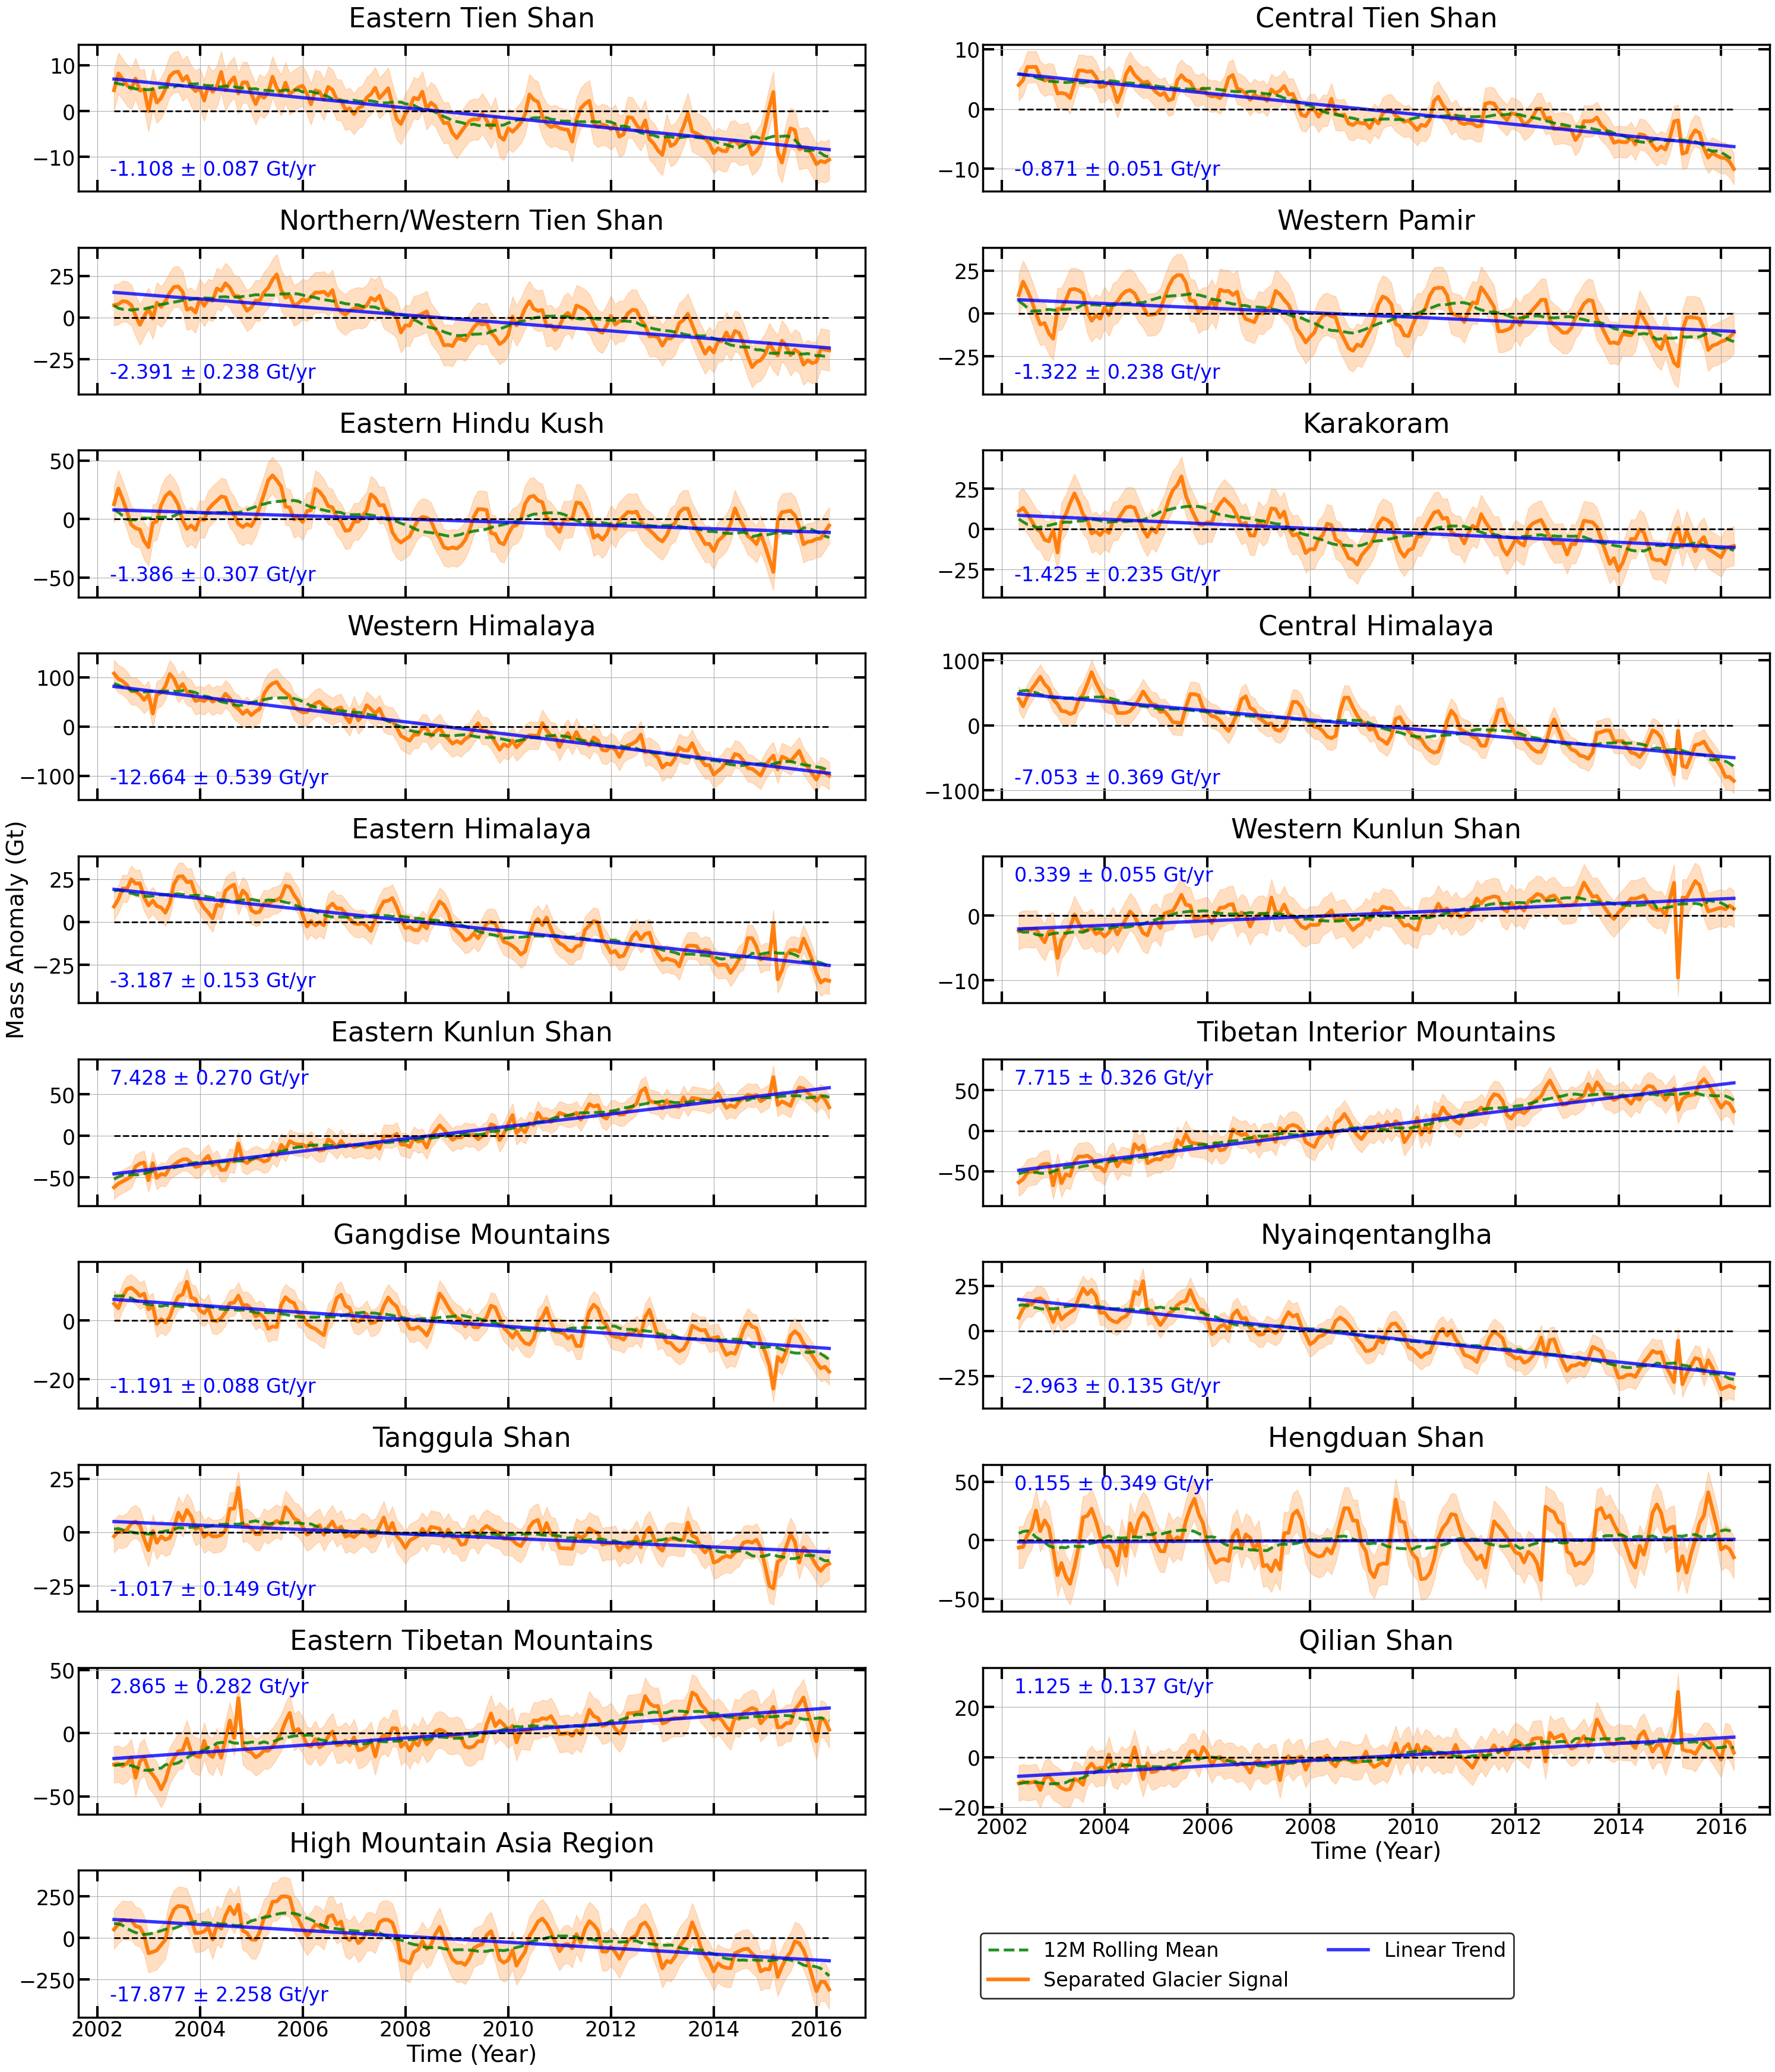

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

# Load region trends and uncertainty table (make sure region/titles match!)
trends_df = pd.read_csv('SH_VCE_EWA_with_VLM_corr_glacier_subregion_trends_Gt_per_year_withUncertainty.csv')

# Set up lookup for region annotation
trend_lookup = trends_df.set_index('Primary_ID').to_dict(orient='index')

# Define datasets and colors
datasets = {
    "Separated Glacier Signal": "Updated_HMA_RegionalAveraged_TWS_GlacierSignal_inGT_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv",
}



dataset_colors = {
    "Separated Glacier Signal": "#ff7f0e",  # Orange
}

# Load region metadata and sort by region_id
region_metadata = pd.DataFrame({
    'region': [
        'Eastern Hindu Kush', 'Western Himalaya', 'Eastern Himalaya', 'Central Himalaya', 'Karakoram',
        'Western Pamir', 'Northern/Western Tien Shan', 'Western Kunlun Shan', 'Nyainqentanglha',
        'Gangdise Mountains', 'Hengduan Shan', 'Tibetan Interior Mountains', 'Tanggula Shan',
        'Eastern Tibetan Mountains', 'Qilian Shan', 'Eastern Kunlun Shan', 'Eastern Tien Shan',
        'Central Tien Shan', 'High Mountain Asia Region'
    ],
    'region_id': [8, 10, 12, 11, 9, 6, 4, 13, 18, 17, 20, 16, 19, 21, 22, 14, 2, 3, 23]
})
region_metadata_sorted = region_metadata.sort_values(by='region_id')
sorted_regions = region_metadata_sorted['region'].values

# Load glacier signal data with datetime index
dfs = {}
for name, file in datasets.items():
    df = pd.read_csv(file)
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    dfs[name] = df[sorted_regions]

# Constants for time conversion to fractional years
YEAR_NS = 365.25 * 24 * 60 * 60 * 1e9
t_ns = dfs["Separated Glacier Signal"].index.view('int64')

# Decomposition model: linear trend + annual & semiannual cycles
def decomp_func(t, a, b, c, d, e, f):
    t = t / YEAR_NS
    linear = a + b * t
    annual = c * np.sin(2 * np.pi * t) + d * np.cos(2 * np.pi * t)
    semi_annual = e * np.sin(4 * np.pi * t) + f * np.cos(4 * np.pi * t)
    return linear + annual + semi_annual

# Setup plot axes: 10 rows x 2 cols for 19 regions
fig, axes = plt.subplots(10, 2, figsize=(30, 36), sharex=True, sharey=False)
axes = axes.flatten()

time_index = dfs["Separated Glacier Signal"].index
start_year = time_index.min().year
end_year = time_index.max().year
x_ticks = pd.date_range(start=f'{start_year}', end=f'{end_year}', freq='2YS')

handle_labels = {}

for i, (_, row) in enumerate(region_metadata_sorted.iterrows()):
    region = row['region']
    region_id = row['region_id']
    ax = axes[i]
    df = dfs["Separated Glacier Signal"]
    y = df[region].values
    mask = np.isfinite(y)

    # Plot original monthly glacier signal
    raw_line, = ax.plot(
        df.index,
        y,
        color=dataset_colors["Separated Glacier Signal"],
        linestyle='-',
        # marker='o',
        linewidth=4.5,
        label="Separated Glacier Signal"
    )

    # --- Plot 12-month moving average (green line)
    roll_mean = df[region].rolling(window=12, center=True, min_periods=1).mean()
    roll_line, = ax.plot(
        roll_mean.index, roll_mean.values,
        color='green',
        linewidth=3.5,
        alpha=0.85,
        linestyle='--',
        label="12M Rolling Mean"
    )
    if i == 0:
        handle_labels["12M Rolling Mean"] = roll_line

    if mask.sum() > 6:
        try:
            # Fit decomposition model to monthly data
            params, _ = curve_fit(decomp_func, t_ns[mask], y[mask], p0=[np.nanmean(y), 0, 0, 0, 0, 0])
            a, b, c, d, e, f = params

            # Compute fitted model values over full time series
            fitted_curve = decomp_func(t_ns, *params)

            # Residuals = original - fitted
            residuals = y - fitted_curve
            resid_std = np.nanstd(residuals)

            # Linear trend line a + b*t (t in fractional years)
            t_fractional = t_ns / YEAR_NS
            linear_trend = a + b * t_fractional

            # Plot linear trend line (blue dashed)
            trend_plot, = ax.plot(
                df.index,
                linear_trend,
                color='blue',
                linestyle='-',
                linewidth=4,
                alpha=0.8,
                label="Linear Trend"
            )

            # Plot uncertainty envelope around fitted curve: ± 2 sigma of residuals
            upper_bound = y + 2 * resid_std
            lower_bound = y - 2 * resid_std

            ax.fill_between(
                df.index,
                lower_bound,
                upper_bound,
                color=dataset_colors["Separated Glacier Signal"],
                alpha=0.25,
                label="Uncertainty Envelope" if i == 0 else None
            )

            # Collect handles for legend only once
            if i == 0:
                handle_labels["Separated Glacier Signal"] = raw_line
                handle_labels["Linear Trend"] = trend_plot

        except RuntimeError:
            # If fit fails, skip plotting trend and envelope
            pass
    # ---- Annotation: Linear trend/uncertainty for region ----
    info = trend_lookup.get(region, None)
    if info is not None:
        annotation = f"{info['trend ± uncertainty (Gt/yr)']} Gt/yr"

        # Lower left (axes fraction coords)
        x_pos, y_pos = 0.04, 0.08
        if i in [9, 10, 11, 15, 16, 17]:
            x_pos, y_pos = 0.04, 0.8
        ax.text(
            x_pos, y_pos, annotation,
            transform=ax.transAxes,
            fontsize=24,
            verticalalignment='bottom',
            color='blue', 
            horizontalalignment='left'
            # bbox=dict(facecolor='white', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.3')
        )


    ax.set_title(region, fontsize=33, pad=22)
    ax.grid(True)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([tick.year for tick in x_ticks], rotation=0)
    ax.tick_params(axis='x', labelsize=25, direction='in', top=True, bottom=True, length=14, width=3)
    ax.tick_params(axis='y', labelsize=25, direction='in', left=True, right=True, length=14, width=3)
    ax.hlines(0, time_index.min(), time_index.max(), colors='k', linestyles='--', linewidth=2)

# Set thick black border for each subplot
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_edgecolor('black')

# Set axis labels
axes[8].set_ylabel('Mass Anomaly (Gt)', fontsize=28)
axes[17].set_xlabel('Time (Year)', fontsize=28)
axes[18].set_xlabel('Time (Year)', fontsize=28)
axes[17].tick_params(labelbottom=True)
axes[17].xaxis.get_label().set_visible(True)

# Legend on one axis (e.g., axes[18])
legend = axes[18].legend(
    handle_labels.values(),
    handle_labels.keys(),
    loc='center left',
    bbox_to_anchor=(1.134, 0.35),
    ncol=2,
    fontsize=24,
    frameon=True
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2)
axes[18].tick_params(labelbottom=True)

# Remove unused subplots if extra
for j in range(len(region_metadata_sorted), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95, wspace=0.15)

# Uncomment to save figure:
plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Figures/Thesis_TimeSeries/Approaches/Wahr_approach/GlacierSignal_SH_VCE_EWA_VLM_corr_LinearTrend_MovingAverage_withEnvelope.png', dpi=300, bbox_inches='tight')

plt.show()

----
-----

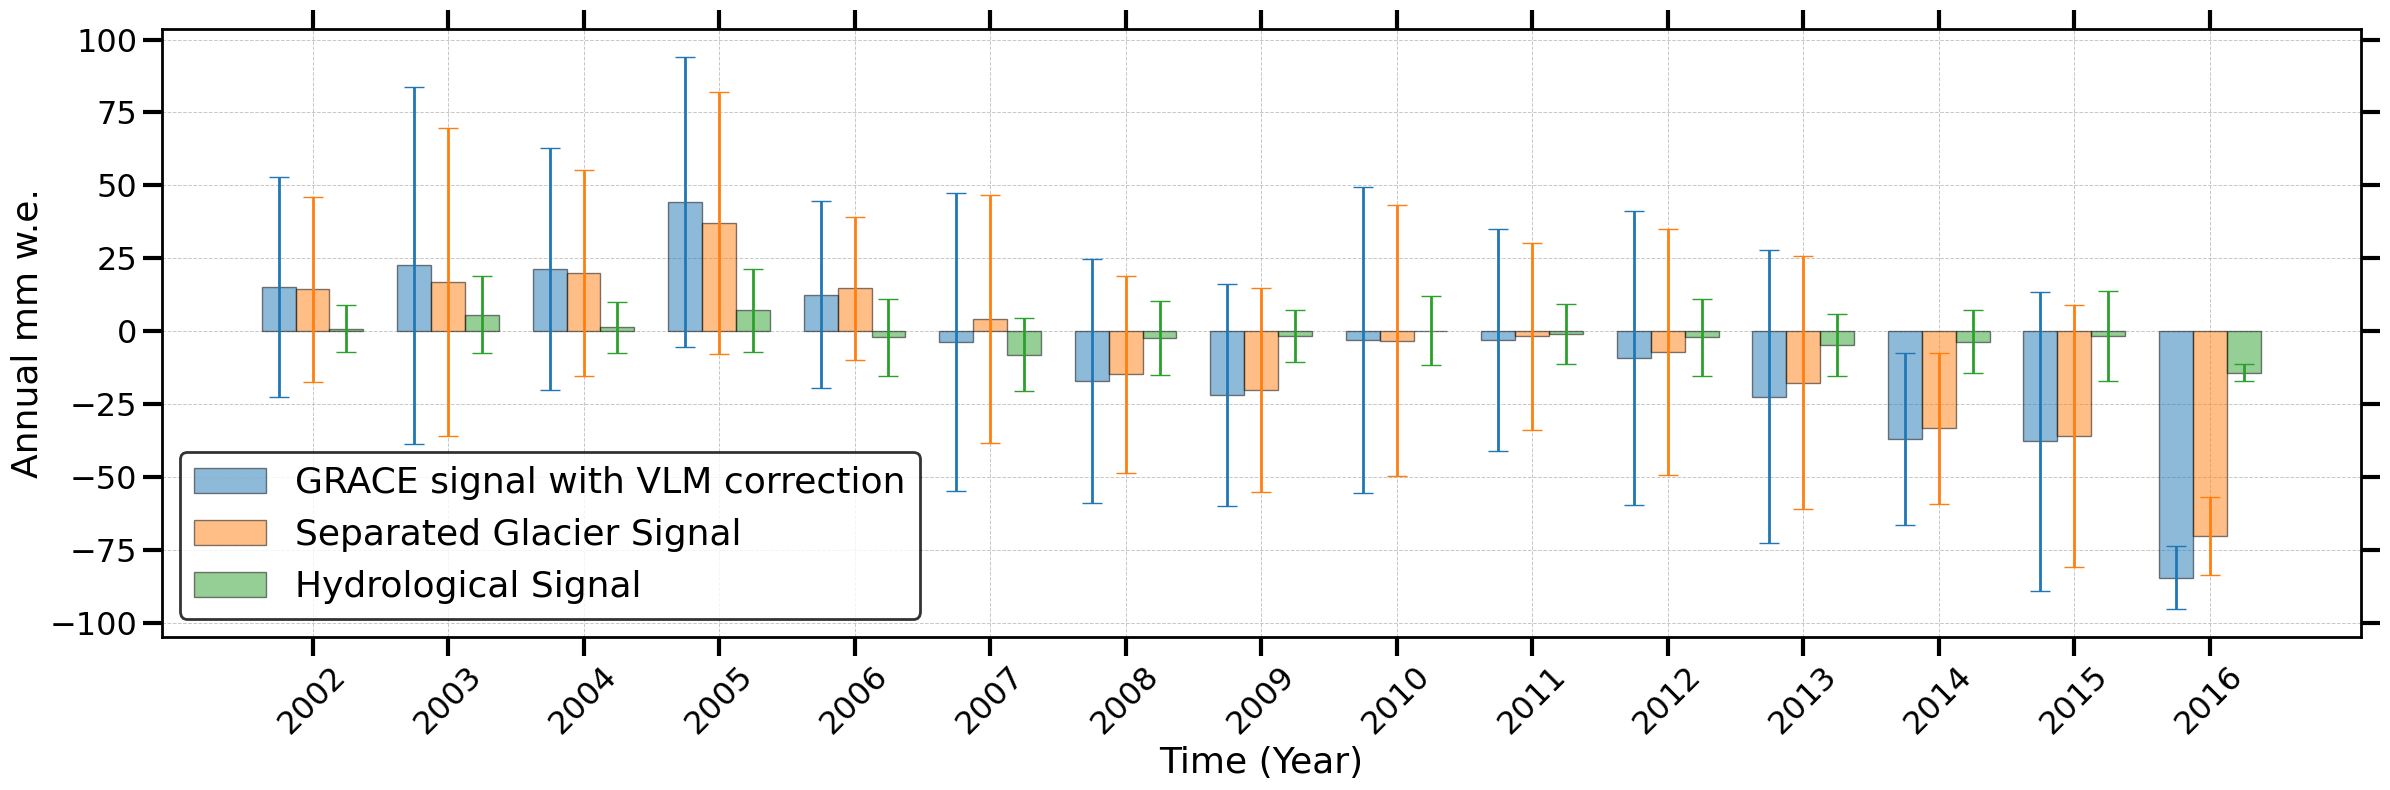

In [35]:
# --- Load datasets as in your code ---
datasets = {
    "GRACE signal with VLM correction": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/SH_EWA_SECorerected_RA_sol_scaled_region_sorted.csv",
    "Separated Glacier Signal": "Updated_HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv", #date column renamed as time to make consistency with others
    "Hydrological Signal": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/WGAP_HM/New_HMA_RegionalAvergaed_anomalies_wghTWS.csv" #New_HMA_RegionalAvergaed_anomalies_wghTWS.csv
}

dataset_colors = {
    "GRACE signal with VLM correction": "#1f77b4",       # Blue
    "Separated Glacier Signal": "#ff7f0e",   # Orange
    "Hydrological Signal": "#2ca02c"         # Green
}

# Load all datasets into DataFrames
dfs = {}
for name, file in datasets.items():
    df = pd.read_csv(file)
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    dfs[name] = df

# ---- Select region (example: 'Eastern Hindu Kush') ----
region = 'High Mountain Asia Region'  # Change as needed

# ---- Prepare annual means and stds for each signal ----
annual_means = {}
annual_stds = {}
for name in datasets.keys():
    # Get the monthly time series for the region
    series = dfs[name][region]
    # Resample to annual mean and std
    annual_mean = series.resample('Y').mean()
    annual_std = series.resample('Y').std()
    annual_means[name] = annual_mean
    annual_stds[name] = annual_std

# ---- Prepare data for plotting ----
years = annual_means["GRACE signal with VLM correction"].index.year
signals = ["GRACE signal with VLM correction", "Separated Glacier Signal", "Hydrological Signal"]
colors = [dataset_colors[s] for s in signals]

x = np.arange(len(years))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(24, 8))

for i, (signal, color) in enumerate(zip(signals, colors)):
    ax.bar(
        x + i * bar_width,
        annual_means[signal],
        width=bar_width,
        yerr=2 * annual_stds[signal],  # 2-sigma error bars
        label=signal,
        color=color,
        capsize=5,
        edgecolor='black',
        alpha=0.5,
        error_kw=dict(ecolor=color, capsize=7, elinewidth=2)  # Error bar color matches bar color
    )

# ---- Formatting ----
ax.set_xticks(x + bar_width)
ax.set_xticklabels(years, rotation=45, fontsize=23)
# ax.tick_params(axis='y', labelsize=23) 

ax.tick_params(axis='x', labelsize=23, direction='out', top=True, bottom=True, length=14, width=3)
ax.tick_params(axis='y', labelsize=23, direction='out', left=True, right=True, length=14, width=3)

ax.set_ylabel("Annual mm w.e.", fontsize=26)
ax.set_xlabel("Time (Year)", fontsize=26)
#  ax.set_title(f"Annual Contributions of Glacier, Hydrological, and GRACE Signals\n({region})", fontsize=16, pad=15)
legend = ax.legend(fontsize=26, loc="lower left")
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2)

ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
ax.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

for spine in ax.spines.values():        # Thicken and darken subplot edge
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

plt.tight_layout()

plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Figures/Thesis_TimeSeries/Approaches/Wahr_approach/Error_Bar_GRACESignalwithVLMCorr_glaciersignal_HS__SH_VCE_EWA_VLM_corr.png', dpi=300, bbox_inches='tight')
plt.show()

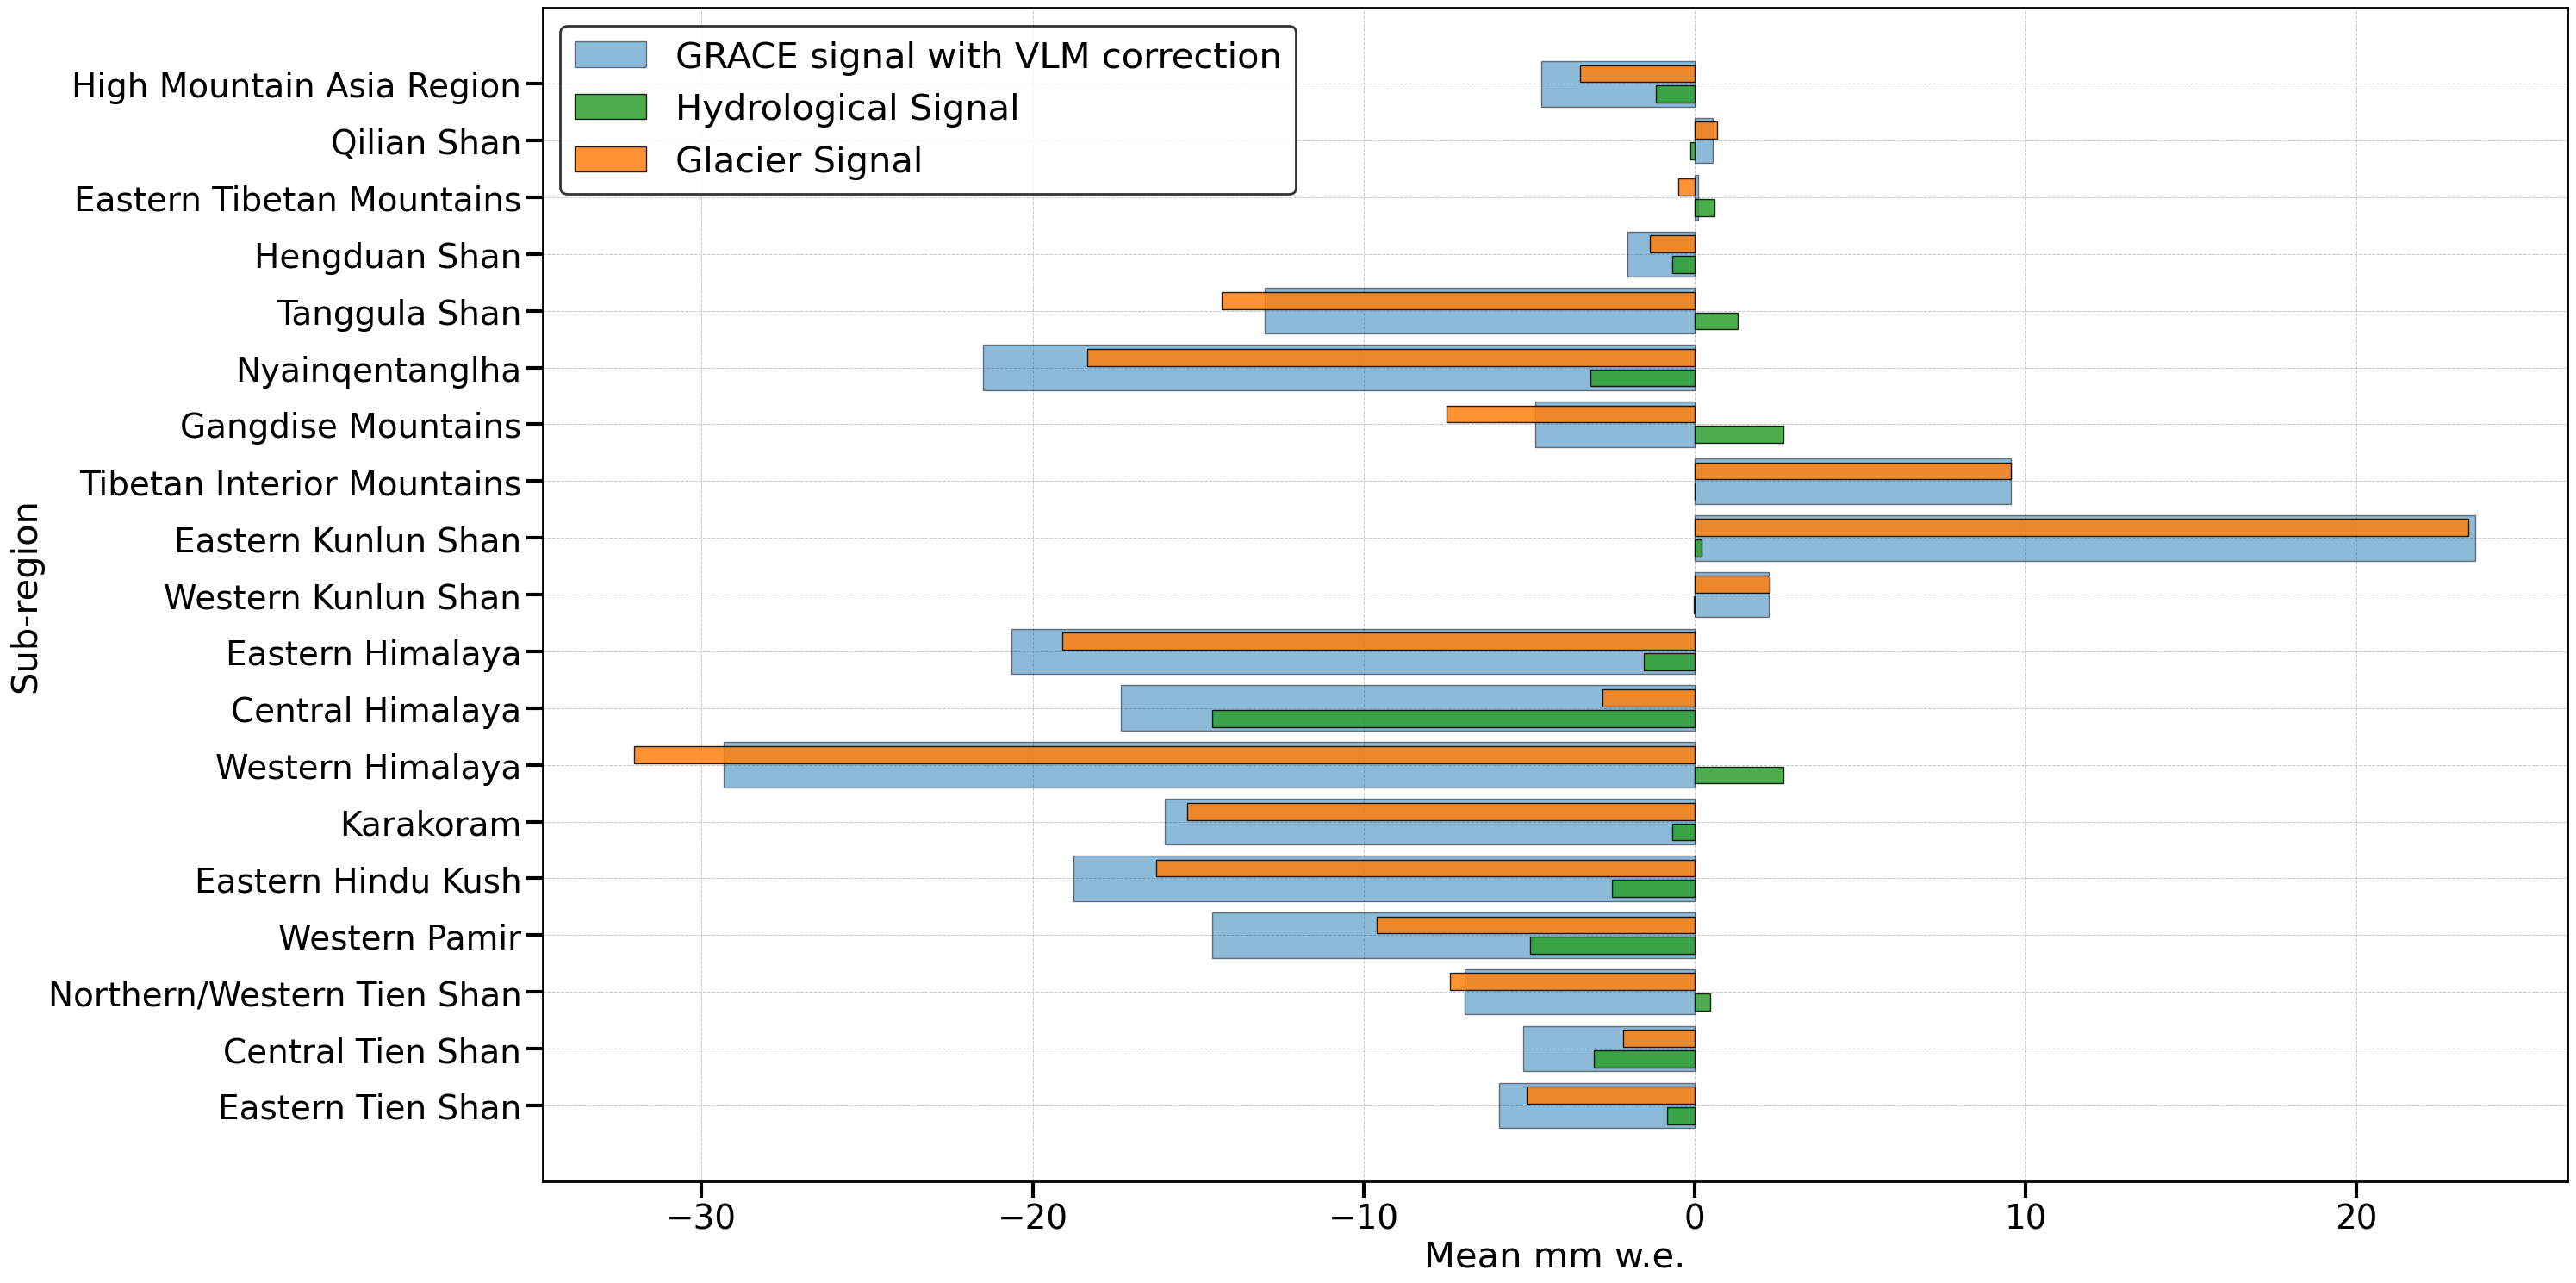

In [36]:
# --- Load data as in your code ---
datasets = {
    "GRACE signal with VLM correction": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Wahr_approach/SH_EWA_SECorerected_RA_sol_scaled_region_sorted.csv",
    "Separated Glacier Signal": "Updated_HMA_RegionalAveraged_TWS_GlacierSignal_for_SH_VCE_EWA_with_VLM_corr_withAnomaliesWGH.csv", #date column renamed as time to make consistency with others
    "Hydrological Signal": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/WGAP_HM/New_HMA_RegionalAvergaed_anomalies_wghTWS.csv" #New_HMA_RegionalAvergaed_anomalies_wghTWS.csv
}

dataset_colors = {
    "GRACE signal with VLM correction": "#1f77b4",       # Blue
    "Separated Glacier Signal": "#ff7f0e",   # Orange
    "Hydrological Signal": "#2ca02c"         # Green
}



region_metadata = pd.DataFrame({
    'region': [
        'Eastern Hindu Kush', 'Western Himalaya', 'Eastern Himalaya', 'Central Himalaya', 'Karakoram',
        'Western Pamir', 'Northern/Western Tien Shan', 'Western Kunlun Shan', 'Nyainqentanglha', 'Gangdise Mountains', 'Hengduan Shan',
        'Tibetan Interior Mountains', 'Tanggula Shan', 'Eastern Tibetan Mountains', 'Qilian Shan', 'Eastern Kunlun Shan',
        'Eastern Tien Shan', 'Central Tien Shan', 'High Mountain Asia Region'
    ],
    'region_id': [8, 10, 12, 11, 9, 6, 4, 13, 18, 17, 20, 16, 19, 21, 22, 14, 2, 3, 23]
})
region_metadata_sorted = region_metadata.sort_values(by='region_id')
sorted_regions = region_metadata_sorted['region'].values

# Load and preprocess all datasets
dfs = {}
for name, file in datasets.items():
    df = pd.read_csv(file)
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    dfs[name] = df[sorted_regions]  # Ensure consistent region order

# --- Calculate mean for each signal and region ---
glacier_means = dfs["Separated Glacier Signal"].mean()
hydro_means = dfs["Hydrological Signal"].mean()
grace_means = dfs["GRACE signal with VLM correction"].mean()


# --- Assume your data loading and mean calculation as before ---

# y positions for each region
y = np.arange(len(sorted_regions))
bar_height_grace = 0.8
bar_height_component = 0.3

# Offsets for side-by-side bars
offset = 0.18  # Adjust for spacing

fig, ax = plt.subplots(figsize=(30, 15))

# 1. Plot GRACE signal as the widest, centered bar
ax.barh(
    y,
    grace_means[sorted_regions],
    height=bar_height_grace,
    color=dataset_colors["GRACE signal with VLM correction"],
    edgecolor='black',
    label="GRACE signal with VLM correction",
    alpha=0.5,
    zorder=1
)

# 2. Plot Hydrological signal, shifted up
ax.barh(
    y - offset,
    hydro_means[sorted_regions],
    height=bar_height_component,
    color=dataset_colors["Hydrological Signal"],
    edgecolor='black',
    label="Hydrological Signal",
    alpha=0.85,
    zorder=2
)

# 3. Plot Glacier signal, shifted down
ax.barh(
    y + offset,
    glacier_means[sorted_regions],
    height=bar_height_component,
    color=dataset_colors["Separated Glacier Signal"],
    edgecolor='black',
    label="Glacier Signal",
    alpha=0.85,
    zorder=3
)

# --- Formatting ---
ax.set_yticks(y)


ax.tick_params(axis='x', labelsize=28, direction='out', top=False, bottom=True, length=14, width=3)
ax.tick_params(axis='y', labelsize=28, direction='out', left=True, right=False, length=14, width=3)


ax.set_yticklabels(sorted_regions, fontsize=28)


ax.set_xlabel("Mean mm w.e.", fontsize=30)
ax.set_ylabel("Sub-region", fontsize=30)
#ax.set_title("Mean GRACE, Hydrological, and Glacier Signal Contributions\nfor Each High Mountain Asia Sub-region", fontsize=16, pad=15)

# Avoid duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), loc="lower right", fontsize=12)

legend = ax.legend(fontsize=30, loc="upper left")
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2)

ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
ax.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

for spine in ax.spines.values():        # Thicken and darken subplot edge
    spine.set_linewidth(2)
    spine.set_edgecolor('black')


plt.tight_layout()
plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Figures/Thesis_TimeSeries/Approaches/Wahr_approach/BarChart_GS_HS_GRACE_Signal_with_VLM_Corr_SH_VCE_EWA_VLM_Corr.png', dpi=300, bbox_inches='tight')
plt.show()

----
-----